In [1]:
# important library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rcParams
from matplotlib.cm import rainbow
import warnings
warnings.filterwarnings("ignore")


# 1- Loading libaries and Dataset

In [2]:
# * Predict the remaining useful life (RUL) of the batteries.

In [3]:
# loading Dataset
df=pd.read_csv("Battery_RUL.csv")
df.head(25)


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001000,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992000,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993000,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016000,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992000,53213.54,56699.65,1107
5,7.0,3301.18,1194.235077,3.674,3.504,5023.633636,5977.38,5977.38,1106
6,8.0,5955.30,1220.135329,4.013,3.501,5017.495000,5967.55,5967.55,1105
7,9.0,5951.20,1220.135329,4.014,3.501,5017.496000,5962.21,5962.21,1104
8,10.0,5945.44,1216.920914,4.014,3.501,5009.993667,5954.91,5954.91,1103
9,11.0,435251.49,263086.078000,4.267,3.086,269.984000,443700.02,443700.02,1102


In [4]:
df.columns

Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL'],
      dtype='object')

# 2- Data Exploration

In [5]:
df = df.round(1)
df

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.3,1151.5,3.7,3.2,5460.0,6755.0,10777.8,1112
1,2.0,7408.6,1172.5,4.2,3.2,5509.0,6762.0,10500.4,1111
2,3.0,7393.8,1113.0,4.2,3.2,5509.0,6762.0,10420.4,1110
3,4.0,7385.5,1080.3,4.2,3.2,5502.0,6762.0,10322.8,1109
4,6.0,65022.8,29813.5,4.3,3.4,5481.0,53213.5,56699.6,1107
...,...,...,...,...,...,...,...,...,...
15059,1108.0,770.4,179.5,3.8,3.7,922.8,1412.4,6678.9,4
15060,1109.0,771.1,179.5,3.8,3.7,915.5,1412.3,6670.4,3
15061,1110.0,769.1,179.4,3.8,3.7,915.5,1412.3,6637.1,2
15062,1111.0,773.9,162.4,3.8,3.8,539.4,1148.0,7660.6,1


Data validation and preprocessing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15064 entries, 0 to 15063
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Cycle_Index                15064 non-null  float64
 1   Discharge Time (s)         15064 non-null  float64
 2   Decrement 3.6-3.4V (s)     15064 non-null  float64
 3   Max. Voltage Dischar. (V)  15064 non-null  float64
 4   Min. Voltage Charg. (V)    15064 non-null  float64
 5   Time at 4.15V (s)          15064 non-null  float64
 6   Time constant current (s)  15064 non-null  float64
 7   Charging time (s)          15064 non-null  float64
 8   RUL                        15064 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.0 MB


Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64

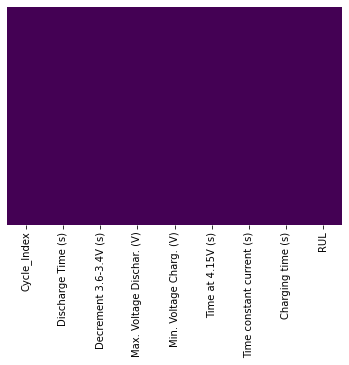

In [6]:
df.info()
#Lets now check for null fields
import seaborn as sns
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
df.isnull().sum()

* NO null values

In [7]:
# Duplicates VALUE 
print(f'Duplicates in the dataset: {df.duplicated().sum()}')
print(f'Percentage of duplicates: {df.duplicated().sum()/len(df)*100}%') # if 0.0 % that means No Duplicate data

Duplicates in the dataset: 0
Percentage of duplicates: 0.0%


*  In datasetb, there are no duplicate values.

In [8]:
#Cardinality 
df.nunique() # To determine the maximum and minimum number of variations in each column of the dataset

Cycle_Index                  1124
Discharge Time (s)           8150
Decrement 3.6-3.4V (s)       3077
Max. Voltage Dischar. (V)      12
Min. Voltage Charg. (V)        15
Time at 4.15V (s)            4425
Time constant current (s)    1498
Charging time (s)            9393
RUL                          1133
dtype: int64

# 3- Statistics

In [9]:
# data describtio
df.describe().T.style.background_gradient()# Significant higher and lower values in a dataset are highlighted
 

,count,mean,std,min,25%,50%,75%,max
Cycle_Index,15064.000000,556.155005,322.378480,1.000000,271.000000,560.000000,833.000000,1134.000000
Discharge Time (s),15064.000000,4581.274296,33144.012270,8.700000,1169.300000,1557.200000,1908.000000,958320.400000
Decrement 3.6-3.4V (s),15064.000000,1239.784499,15039.589157,-397645.900000,319.600000,439.250000,600.000000,406703.800000
Max. Voltage Dischar. (V),15064.000000,3.908829,0.095384,3.000000,3.800000,3.900000,4.000000,4.400000
Min. Voltage Charg. (V),15064.000000,3.578658,0.127109,3.000000,3.500000,3.600000,3.700000,4.400000
Time at 4.15V (s),15064.000000,3768.333922,9129.552904,-113.600000,1828.900000,2930.200000,4088.300000,245101.100000
Time constant current (s),15064.000000,5461.264186,25155.845223,6.000000,2564.300000,3824.300000,5012.400000,880728.100000
Charging time (s),15064.000000,10066.495433,26415.353926,6.000000,7841.925000,8320.400000,8763.250000,880728.100000
RUL,15064.000000,554.194172,322.434514,0.000000,277.000000,551.000000,839.000000,1133.000000


# 4- Data Engineering

array([[<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>]],
      dtype=object)

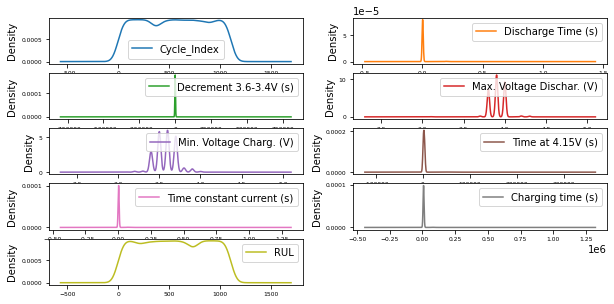

In [10]:
# Let's have a look at the numerical value density.
df.plot(kind='density', subplots=True, layout=(10,2), sharex=False, 
                     sharey=False,fontsize=6, figsize=(10,10))# Let's have a look at the numerical value density.

* Let's figure out how to interlink column corelatons for a better understanding.

HEATMAP


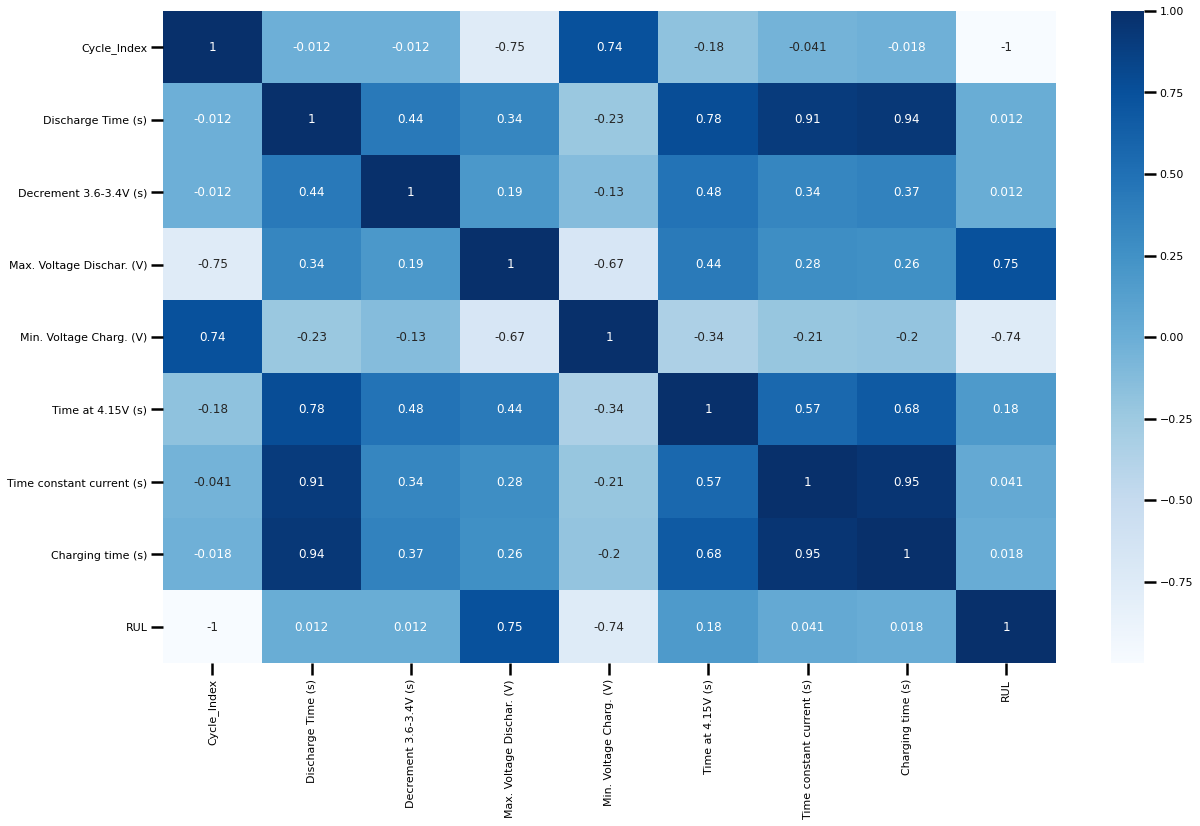

In [14]:
# heatmap graph for finding  correlation of column 
print("HEATMAP")
#get the correlation
sns.set_context('poster', font_scale=0.5)
plt.figure(figsize=(20,12))
cor = df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Blues)
plt.show()

*  # Output variable columns have a correlation.

In [12]:
#Correlation with output variable
cor_target = abs(cor["Time constant current (s)"])
#Selecting highly correlated features
relevant_features = cor_target #[cor_target>0.5]
relevant_features


Cycle_Index                  0.040622
Discharge Time (s)           0.912536
Decrement 3.6-3.4V (s)       0.343228
Max. Voltage Dischar. (V)    0.276616
Min. Voltage Charg. (V)      0.210858
Time at 4.15V (s)            0.568922
Time constant current (s)    1.000000
Charging time (s)            0.953522
RUL                          0.040675
Name: Time constant current (s), dtype: float64

In [13]:
relevant_features = cor_target [cor_target>0.5]
relevant_features

Discharge Time (s)           0.912536
Time at 4.15V (s)            0.568922
Time constant current (s)    1.000000
Charging time (s)            0.953522
Name: Time constant current (s), dtype: float64

*  The following columns have a strong relationship.
[Time to Discharge (s)] 0.912536

[Time (s) at 4.15V] 0.568922

[Constant current time (s)] 1.000000

[Charging time in seconds] 0.953522

<AxesSubplot:>

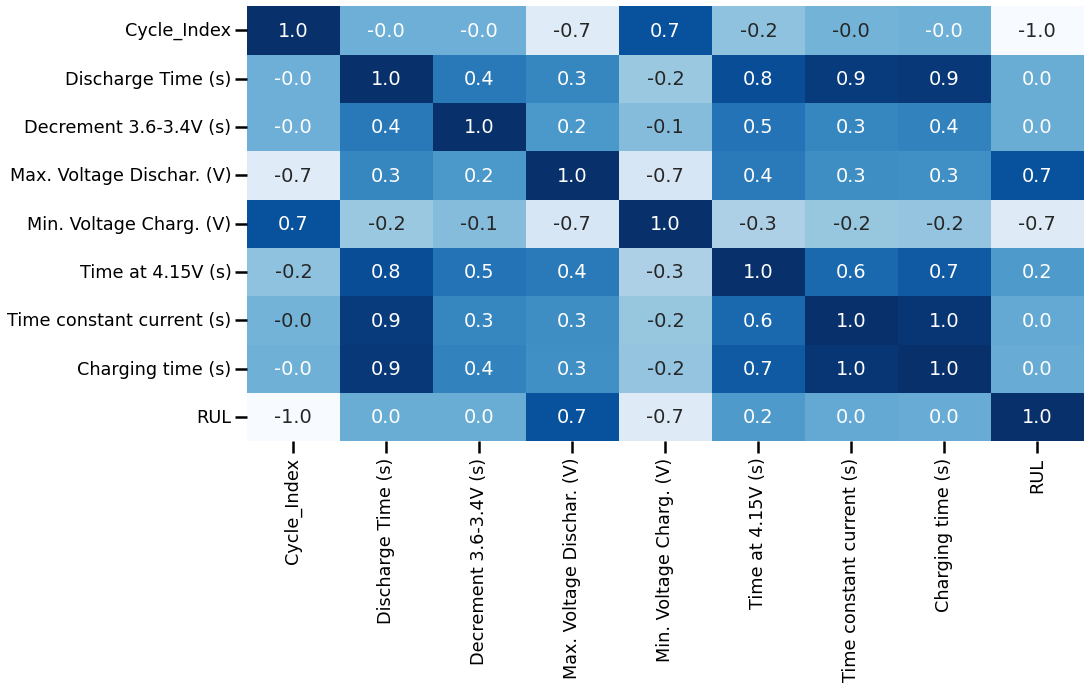

In [14]:
# High Correlation Columns Heatmap¶
plt.figure(figsize=(15,8))
sns.set_context('poster', font_scale=0.8)
sns.heatmap(df.corr(),annot=True, cbar=False, cmap='Blues', fmt='.1f')

* Observations:

RUL's most essential factors ( Predict the remaining useful life ) is , Time constant current (s), Charging time (s), and Maximum Voltage Discharge (V) in Time at 4.15V (s)' Reduce the voltage to 3.6-3.4V. (s)


# Examine the Contribution of Each Column in the Dataset

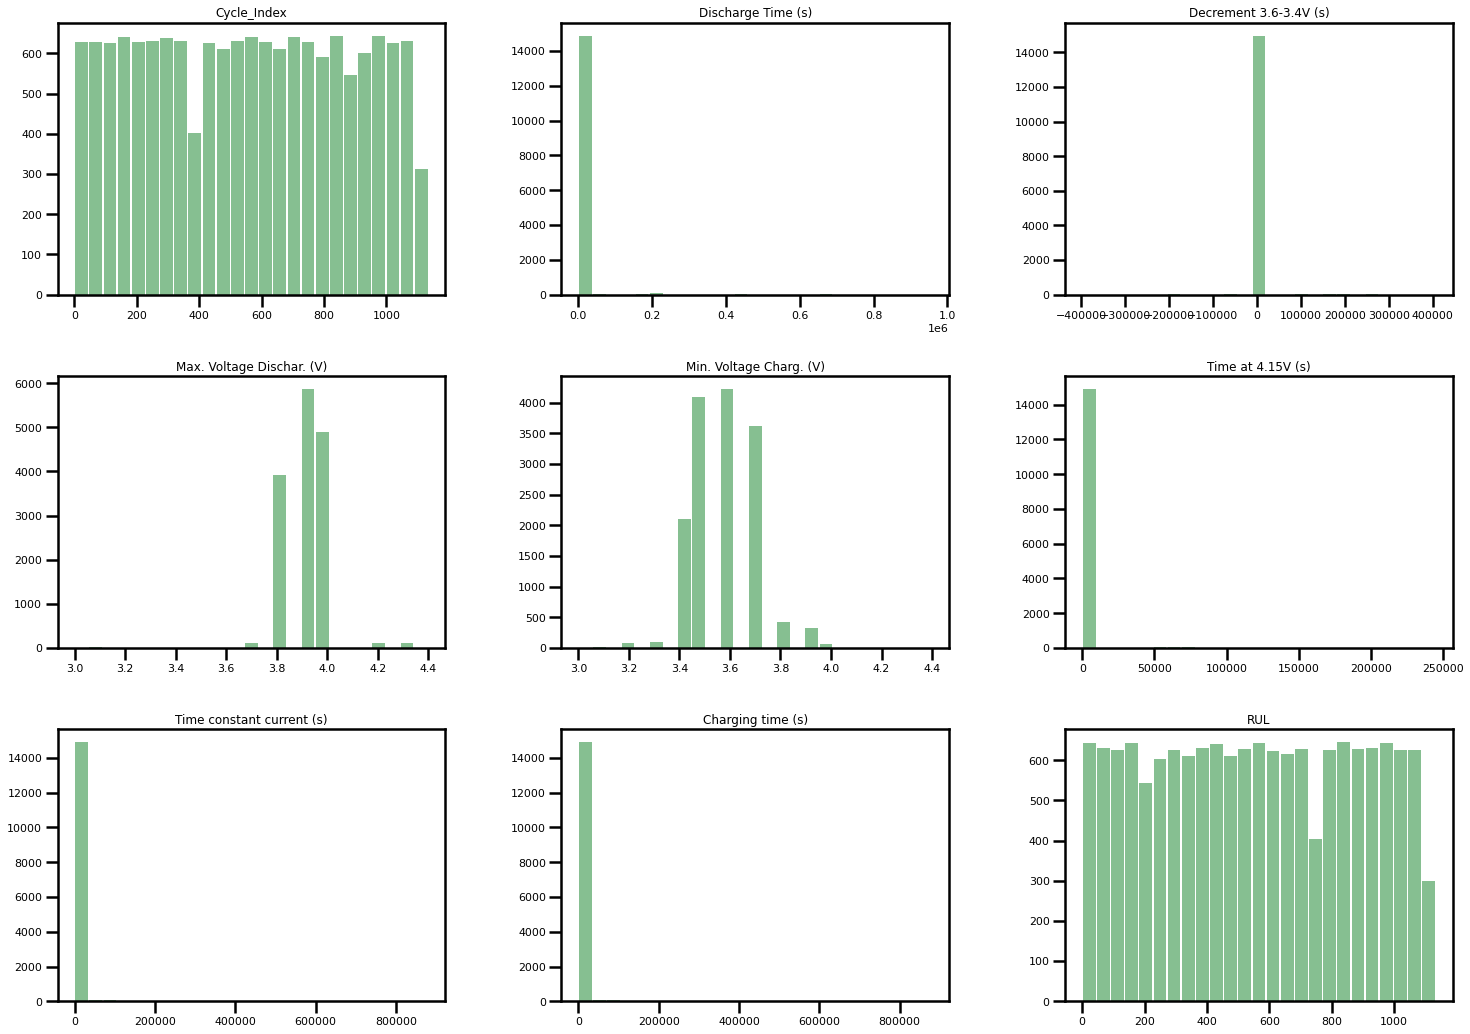

In [15]:
#study the data
sns.set_context('poster', font_scale=0.5)
df.hist(bins=25, grid=False, figsize=(25,18), color='#86bf91', zorder=2, rwidth=0.9)
plt.show()

# 5- Data Visualization

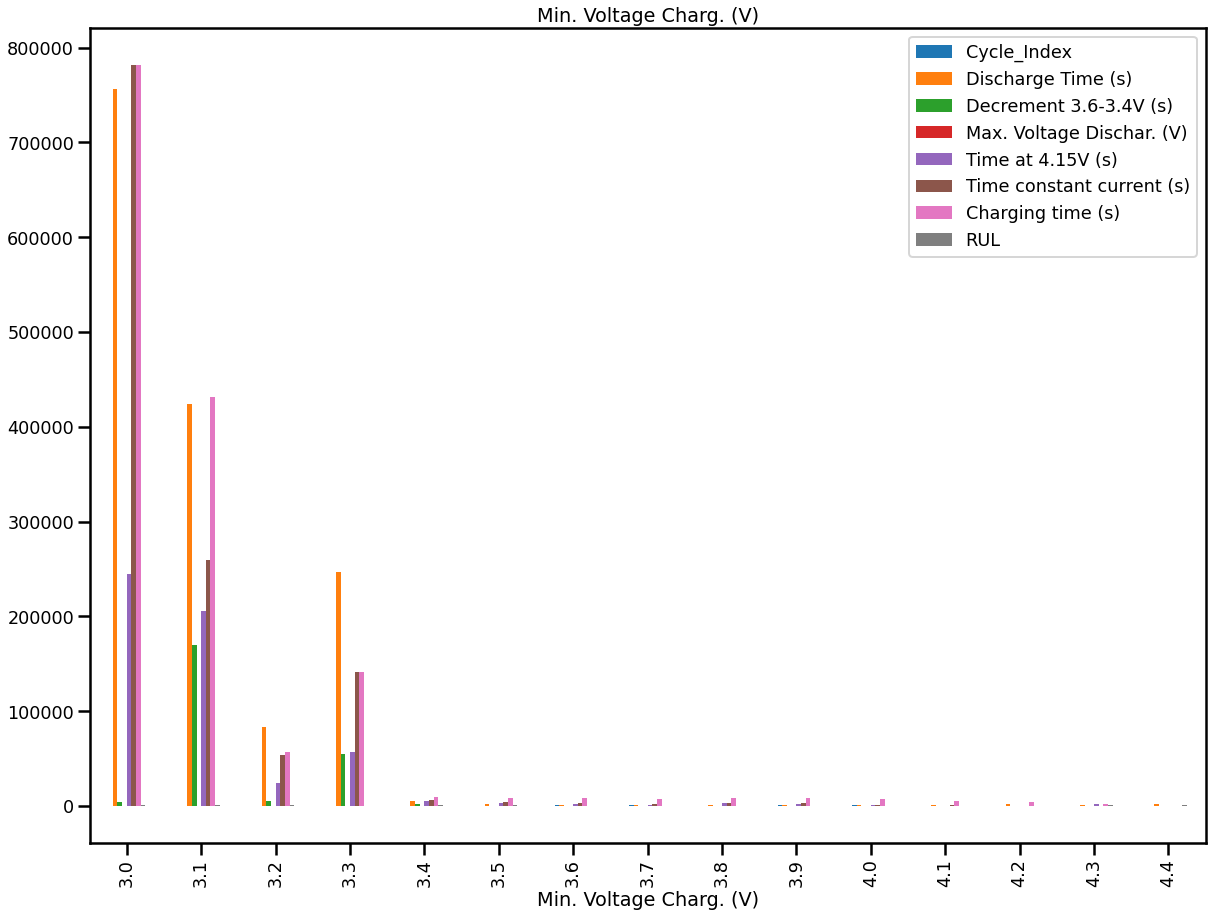

In [16]:
# data visualisation on [ Min. Voltage Charg. (V) ]
sns.set_context('poster', font_scale=0.8)
df.groupby('Min. Voltage Charg. (V)').mean().plot(kind='bar', figsize=(20,15)) 
plt.xlabel('Min. Voltage Charg. (V)')
#plt.ylabel('')
plt.title('Min. Voltage Charg. (V)')
plt.show()


* Factors to Consider:

The colummn parametor Min. Voltage Charg. (V) is dependent on voltage 3.0>>3.1>>3.3>>3.2.

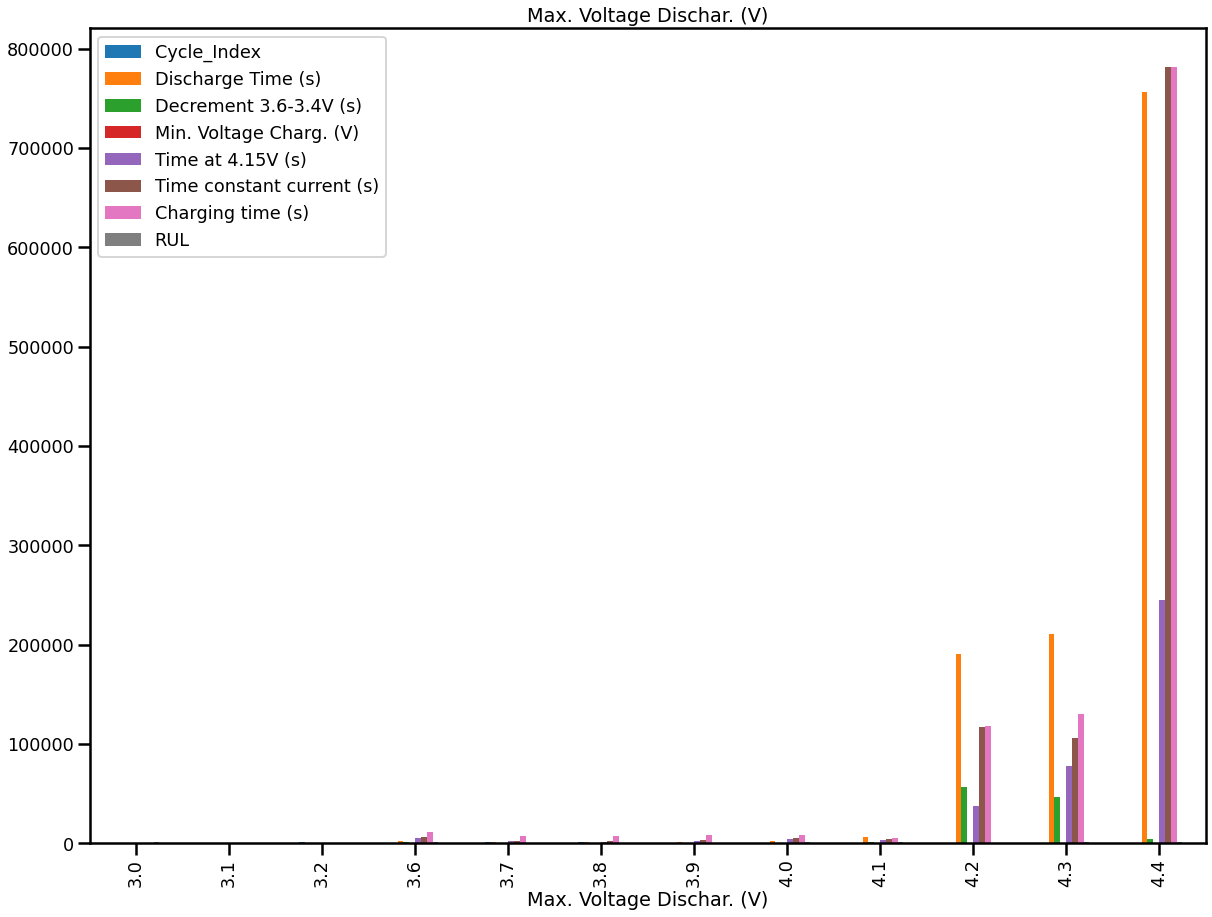

In [17]:
# data visualisation on [ Max. Voltage Dischar. (V) ]
sns.set_context('poster', font_scale=0.8)
df.groupby('Max. Voltage Dischar. (V)').mean().plot(kind='bar', figsize=(20,15)) 
plt.xlabel('Max. Voltage Dischar. (V)')
#plt.ylabel('')
plt.title('Max. Voltage Dischar. (V)')
plt.show()


* * Factors to Consider:

The colummn parametor Max. Voltage Discharge (V) is dependent on the voltage 4.4>>4.3>>4.2.

In [18]:
import plotly.express as px
import plotly.graph_objects as go


In [19]:
 px.line(df, x='Cycle_Index', y='Time constant current (s)')

In [20]:
fig = go.Figure(data=[go.Histogram(x=df, cumulative_enabled=True)])
fig.show()

In [21]:
fig = px.histogram(df, x="Max. Voltage Dischar. (V)", nbins=30)
fig.show()


* * Factors to Consider:

The maximum voltage discharge (V) is 3.9 volts.

In [22]:
fig = px.histogram(df, x="Min. Voltage Charg. (V)", nbins=30)
fig.show()


* Factors to Consider:

The maximum charging voltage (V) is 3.6 volts.

# 6-Epilogue

Time constant current (s), Charging time (s), and Maximum Voltage Discharge (V) in Time at 4.15V (s) are the most important RUL variables (predict the remaining useful life). Lower the voltage to around 3.6-3.4 volts (s)
The column parameter Min. Voltage Charg. (V) is affected by the voltage 3.0>>3.1>>3.3>>
3.2. The column parametor Max. Voltage Discharge (V) is proportional to the voltage 4.4>>4.3>>
3.9 volts is the highest voltage discharge (V).
3.6 volts (V) is the maximum charging voltage.